# Notebook 02 · EDA de Ítems & Categorías
> **Nexus RecSys** — Sistema de Recomendación · Retailrocket Dataset

---

| Campo | Detalle |
|---|---|
| **Fuentes** | `item_properties_part1.csv` · `item_properties_part2.csv` · `category_tree.csv` |
| **Checkpoints de salida** | `cp02_items_flat.parquet` · `cp02_category_enriched.parquet` |
| **Objetivo** | Explorar propiedades de ítems, aplanar el snapshot-log a tabla wide y resolver la jerarquía del árbol de categorías para enriquecer el merge posterior |

---

### Contexto de los datos

**`item_properties`** es un **snapshot-log**: cada fila registra el valor de un atributo de un ítem en un instante determinado. Un mismo ítem puede tener múltiples entradas a lo largo del tiempo, reflejando cambios en precio, disponibilidad u otras propiedades. Para que sea útil en modelado, este formato vertical debe aplanarse a una tabla **wide** (una fila por ítem).

**`category_tree`** define la **jerarquía taxonómica** del catálogo mediante relaciones padre-hijo. A partir de ella se puede reconstruir el árbol completo hasta la raíz, calculando la profundidad de cada categoría y su ancestro de primer nivel (`root_category`).

### Mapa del notebook

| Bloque | Descripción |
|---|---|
| **A** · Propiedades | Carga y concatenación de parts 1 y 2, EDA, aplanado snapshot-log → tabla wide |
| **B** · Categorías | Carga de `category_tree`, resolución iterativa de la jerarquía, cálculo de nivel y raíz |


In [1]:
# ─── SETUP OBLIGATORIO ───────────────────────────────────────────────────────
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(message)s')
logger = logging.getLogger(__name__)

BASE_DIR   = Path('..')
RAW        = BASE_DIR / 'data' / 'raw'
INTERIM    = BASE_DIR / 'data' / 'interim'
INTERIM.mkdir(parents=True, exist_ok=True)

CHECKPOINT_ITEMS = INTERIM / 'cp02_items_flat.parquet'
CHECKPOINT_CAT   = INTERIM / 'cp02_category_enriched.parquet'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

logger.info("Setup completado. BASE_DIR=%s", BASE_DIR.resolve())


2026-03-12 00:01:33,872 — Setup completado. BASE_DIR=C:\Users\Usuario\Desktop\HENRY\PROYECTO FINAL\EDA PRUEBA\nexus-recsys


---
## Bloque A · Propiedades de Ítems (`item_properties`)

### A1 · Carga y Concatenación de Partes

El dataset de propiedades está dividido en dos archivos (`part1` y `part2`) que se unifican en un único DataFrame. El timestamp se convierte de Unix milisegundos a `datetime` con zona horaria UTC, garantizando consistencia con el log de eventos del Notebook 01.


In [2]:
# ─── A1. CARGA Y CONCATENACIÓN ───────────────────────────────────────────────
logger.info("Cargando item_properties_part1.csv …")
part1 = pd.read_csv(RAW / 'item_properties_part1.csv')
logger.info("part1 shape: %s", part1.shape)

logger.info("Cargando item_properties_part2.csv …")
part2 = pd.read_csv(RAW / 'item_properties_part2.csv')
logger.info("part2 shape: %s", part2.shape)

item_props = pd.concat([part1, part2], ignore_index=True)
del part1, part2  # liberar memoria

# Convertir timestamp Unix ms → datetime UTC
item_props['timestamp'] = pd.to_datetime(item_props['timestamp'], unit='ms', utc=True)

logger.info("item_props concatenado: shape=%s", item_props.shape)
ram_mb = item_props.memory_usage(deep=True).sum() / 1024**2
logger.info("RAM: %.2f MB", ram_mb)

print(f"Shape total: {item_props.shape}  |  RAM: {ram_mb:.2f} MB")
display(item_props.head(3))

# Nulos
nulos = pd.DataFrame({
    'nulos_abs': item_props.isnull().sum(),
    'nulos_pct': (item_props.isnull().mean() * 100).round(2)
})
print("\n── Nulos por columna ──")
display(nulos)


2026-03-12 00:01:37,351 — Cargando item_properties_part1.csv …
2026-03-12 00:01:47,408 — part1 shape: (10999999, 4)
2026-03-12 00:01:47,409 — Cargando item_properties_part2.csv …
2026-03-12 00:01:55,133 — part2 shape: (9275903, 4)
2026-03-12 00:01:55,837 — item_props concatenado: shape=(20275902, 4)
2026-03-12 00:01:55,840 — RAM: 1030.51 MB


Shape total: (20275902, 4)  |  RAM: 1030.51 MB


,timestamp,itemid,property,value
0,2015-06-28 03:00:00+00:00,460429,categoryid,1338
1,2015-09-06 03:00:00+00:00,206783,888,1116713 960601 n277.200
2,2015-08-09 03:00:00+00:00,395014,400,n552.000 639502 n720.000 424566



── Nulos por columna ──


,nulos_abs,nulos_pct
timestamp,0,0.0
itemid,0,0.0
property,0,0.0
value,0,0.0


### A2 · Análisis Exploratorio de Propiedades

Se estudia la distribución de propiedades del catálogo: cuáles aparecen con mayor frecuencia (hay propiedades omnipresentes como `categoryid` y otras casi únicas), cuántas propiedades distintas tiene cada ítem en promedio, y qué fracción de ítems presenta historial de cambios de valor a lo largo del tiempo. Este perfil determina qué propiedades son candidatas viables como features en el modelo.


2026-03-12 00:02:01,153 — Ítems únicos: 417053
2026-03-12 00:02:01,156 — Propiedades únicas: 1104


Ítems únicos       : 417,053
Propiedades únicas : 1,104
Registros totales  : 20,275,902

── Top 15 propiedades más frecuentes ──


,frecuencia
property,
888,3000398
790,1790516
available,1503639
categoryid,788214
6,631471
283,597419
776,574220
678,481966
364,476486


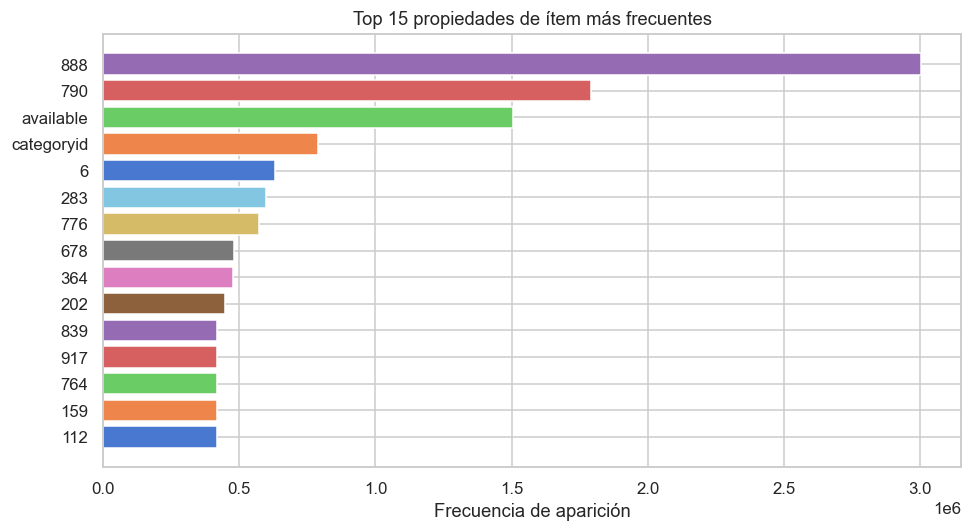


── Propiedades distintas por ítem ──
count    417053.00
mean         28.78
std           7.41
min          12.00
25%          24.00
50%          27.00
75%          31.00
max          59.00
Name: property, dtype: float64


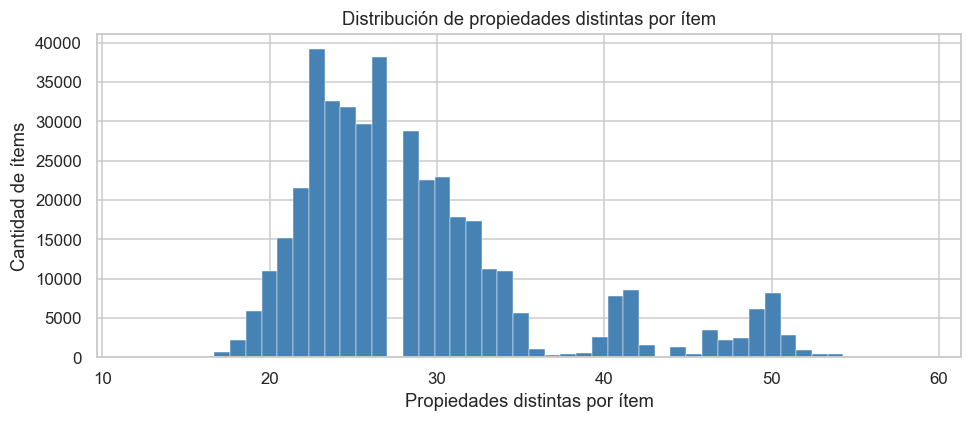

2026-03-12 00:02:11,407 — Ítems con más de 1 timestamp distinto: 416168 (99.79%)



Ítems con historial de cambios: 416,168 (99.79% del total)


In [3]:
# ─── A2. EDA DE PROPIEDADES ──────────────────────────────────────────────────

# Cardinalidades básicas
n_items_unicos     = item_props['itemid'].nunique()
n_props_unicas     = item_props['property'].nunique()
n_registros_totales = len(item_props)

logger.info("Ítems únicos: %d", n_items_unicos)
logger.info("Propiedades únicas: %d", n_props_unicas)
print(f"Ítems únicos       : {n_items_unicos:,}")
print(f"Propiedades únicas : {n_props_unicas:,}")
print(f"Registros totales  : {n_registros_totales:,}")

# Top 15 propiedades más frecuentes
top15_props = item_props['property'].value_counts().head(15)
print("\n── Top 15 propiedades más frecuentes ──")
display(top15_props.to_frame('frecuencia'))

fig, ax = plt.subplots(figsize=(9, 5))
top15_sorted = top15_props.sort_values()
ax.barh(top15_sorted.index, top15_sorted.values, color=sns.color_palette('muted', 15))
ax.set_xlabel('Frecuencia de aparición')
ax.set_title('Top 15 propiedades de ítem más frecuentes')
plt.tight_layout()
plt.show()

# Distribución de propiedades distintas por ítem
props_por_item = item_props.groupby('itemid')['property'].nunique()
print(f"\n── Propiedades distintas por ítem ──")
print(props_por_item.describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(props_por_item, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Propiedades distintas por ítem')
ax.set_ylabel('Cantidad de ítems')
ax.set_title('Distribución de propiedades distintas por ítem')
plt.tight_layout()
plt.show()

# Ítems con más de 1 timestamp distinto (ítems cambiantes)
items_cambiantes = (
    item_props.groupby('itemid')['timestamp']
    .nunique()
    .loc[lambda s: s > 1]
)
pct_cambiantes = len(items_cambiantes) / n_items_unicos * 100
logger.info("Ítems con más de 1 timestamp distinto: %d (%.2f%%)", len(items_cambiantes), pct_cambiantes)
print(f"\nÍtems con historial de cambios: {len(items_cambiantes):,} ({pct_cambiantes:.2f}% del total)")


> #### ⚠️ Limitación conocida — Valores hasheados
>
> Los valores de la columna `value` están **ofuscados** (hashing) por razones de privacidad y confidencialidad comercial. Esto implica que:
>
> - No es posible interpretar semánticamente ningún atributo (precio, marca, descripción, etc.).
> - Solo se puede operar con la **estructura**: qué propiedades existen, con qué frecuencia aparecen y si cambian en el tiempo.
> - La única columna con valor directamente interpretable es `categoryid`, que corresponde al ID numérico de la categoría.
> - En el pipeline de features, los hashes se tratarán como **identificadores de categorías de valor** (variables categóricas).
> - Los modelos basados en similitud de contenido textual o numérico (TF-IDF, embeddings semánticos, features de precio) quedan **arquitectónicamente descartados** para este dataset.
>
> **→ Decisión arquitectónica derivada:** el sistema de recomendación se construirá sobre **filtrado colaborativo** y **señales de categoría** (`categoryid`, `root_category`). No existe contenido semántico explotable más allá de la estructura taxonómica del catálogo. Esta limitación descarta de raíz los enfoques puramente content-based y orienta el diseño hacia modelos híbridos colaborativos + categoría.


### A3 · Aplanado — Una fila por ítem (Last Known Value)

Para cada par `(itemid, property)` se conserva únicamente el **valor más reciente** según timestamp. Luego se aplica un `pivot` para generar una tabla wide con una fila por ítem y una columna por propiedad. Los nombres de columna se normalizan a `snake_case`.


2026-03-12 00:02:45,162 — item_props_latest shape: (12003814, 3)
2026-03-12 00:03:44,411 — items_flat shape: (417053, 1105)


Shape items_flat: (417053, 1105)


,itemid,0,1,10,100,1000,1001,1002,1003,1004,...,992,993,994,995,996,997,998,999,available,categoryid
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,209
1,1,769062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1114
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1305



Columnas con nulos: 1095 de 1105


,pct_nulos
368,100.00
353,100.00
357,100.00
883,100.00
1018,100.00
...,...
776,2.34
6,1.92
202,0.68
917,0.21


2026-03-12 00:03:47,022 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 00:03:47,033 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


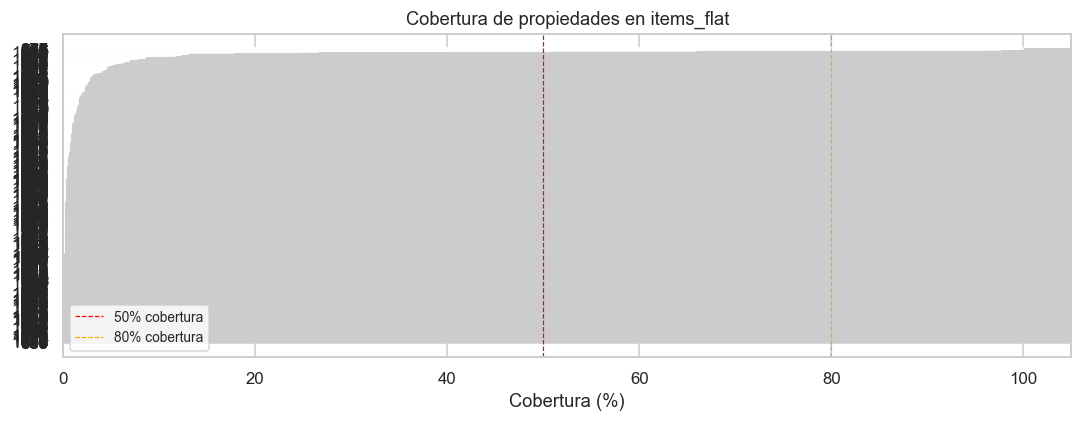

In [4]:
# ─── A3. APLANADO (last known value por ítem × propiedad) ────────────────────

# Para cada par (itemid, property) conservar el valor más reciente
item_props_latest = (
    item_props
    .sort_values('timestamp')
    .groupby(['itemid', 'property'])['value']
    .last()
    .reset_index()
)
logger.info("item_props_latest shape: %s", item_props_latest.shape)

# Pivot: una fila por ítem, columnas = propiedades
items_flat = (
    item_props_latest
    .pivot(index='itemid', columns='property', values='value')
    .reset_index()
)

# Normalizar nombres de columnas a snake_case
items_flat.columns = [
    str(c).lower().replace(' ', '_').replace('-', '_')
    for c in items_flat.columns
]
items_flat.columns.name = None

logger.info("items_flat shape: %s", items_flat.shape)
print(f"Shape items_flat: {items_flat.shape}")
display(items_flat.head(3))

# Reporte de % nulos por columna (solo columnas con al menos 1 nulo)
nulos_flat = (
    items_flat.isnull().mean() * 100
).round(2).sort_values(ascending=False)
nulos_flat = nulos_flat[nulos_flat > 0].rename('pct_nulos')

print(f"\nColumnas con nulos: {len(nulos_flat)} de {items_flat.shape[1]}")
display(nulos_flat.to_frame())

# Visualización densidad de cobertura
fig, ax = plt.subplots(figsize=(10, 4))
cobertura = (100 - nulos_flat).sort_values()
colores = ['#d73027' if v < 50 else '#fee090' if v < 80 else '#1a9850' for v in cobertura]
ax.barh(cobertura.index, cobertura.values, color=colores)
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, label='50% cobertura')
ax.axvline(80, color='orange', linestyle='--', linewidth=0.8, label='80% cobertura')
ax.set_xlabel('Cobertura (%)')
ax.set_title('Cobertura de propiedades en items_flat')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Bloque B — Árbol de Categorías (`category_tree`)

### B1 · Análisis Exploratorio del Árbol

Inspección de la estructura básica del árbol: forma, valores nulos, nodos raíz (sin padre) y nodos hoja (sin hijos).


In [5]:
# ─── B1. EDA BÁSICO — category_tree ─────────────────────────────────────────
cat = pd.read_csv(RAW / 'category_tree.csv')
logger.info("category_tree shape: %s", cat.shape)

print(f"Shape: {cat.shape}")
display(cat.head(5))

# Nulos
nulos_cat = pd.DataFrame({
    'nulos_abs': cat.isnull().sum(),
    'nulos_pct': (cat.isnull().mean() * 100).round(2)
})
print("\n── Nulos por columna ──")
display(nulos_cat)

# Categorías raíz (parentid es nulo)
cat_raiz  = cat[cat['parentid'].isna()]
# Categorías hoja (no aparecen como parent de ninguna otra)
padres    = set(cat['parentid'].dropna().astype(int))
cat_hoja  = cat[~cat['categoryid'].isin(padres)]

logger.info("Categorías raíz (sin padre): %d", len(cat_raiz))
logger.info("Categorías hoja (sin hijos): %d", len(cat_hoja))
print(f"\nCategorías totales : {len(cat):,}")
print(f"Categorías raíz    : {len(cat_raiz):,}")
print(f"Categorías hoja    : {len(cat_hoja):,}")


2026-03-12 00:04:19,099 — category_tree shape: (1669, 2)


Shape: (1669, 2)


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0



── Nulos por columna ──


,nulos_abs,nulos_pct
categoryid,0,0.0
parentid,25,1.5


2026-03-12 00:04:19,114 — Categorías raíz (sin padre): 25
2026-03-12 00:04:19,115 — Categorías hoja (sin hijos): 1307



Categorías totales : 1,669
Categorías raíz    : 25
Categorías hoja    : 1,307


### B2 · Resolución de Jerarquía

Para cada categoría se aplica la función `resolve_hierarchy()`, que escala el árbol hacia arriba hasta alcanzar la raíz. Se calculan dos atributos enriquecidos:

| Columna nueva | Descripción |
|---|---|
| `category_level` | Profundidad del nodo en el árbol (0 = raíz) |
| `root_category` | ID de la categoría raíz correspondiente |


2026-03-12 00:04:23,809 — Resolviendo jerarquía para 1669 categorías …
2026-03-12 00:04:23,815 — Resolución completada.


── Distribución de niveles de jerarquía ──


,cantidad
category_level,
0,25
1,174
2,702
3,665
4,90
5,13


2026-03-12 00:04:24,116 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 00:04:24,117 — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


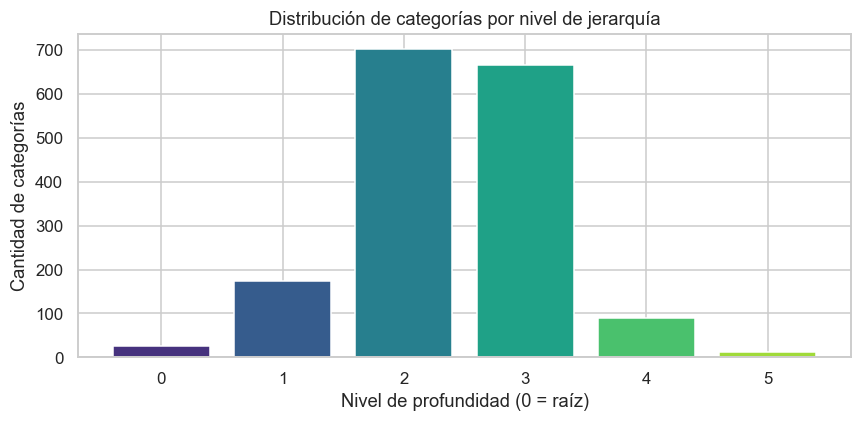


Raíces únicas: 25


,subcategorías
root_category,
140,290
1600,187
653,154
1579,135
1532,130
395,120
1482,101
250,97
1224,70


In [6]:
# ─── B2. RESOLUCIÓN DE JERARQUÍA ─────────────────────────────────────────────

# Mapa parent: categoryid → parentid
parent_map = dict(zip(cat['categoryid'], cat['parentid']))


def resolve_hierarchy(category_id):
    """
    Sube desde category_id hasta la raíz.
    Retorna (nivel, root_category_id).
    Nivel 0 = raíz (sin padre).
    Corta en 20 niveles para evitar ciclos.
    """
    nivel = 0
    current = category_id
    visited = set()
    while True:
        parent = parent_map.get(current)
        if pd.isna(parent):          # llegamos a la raíz
            break
        if current in visited:       # ciclo detectado
            logger.warning("Ciclo detectado en categoryid=%s", category_id)
            break
        visited.add(current)
        current = int(parent)
        nivel += 1
        if nivel >= 20:              # protección adicional
            break
    return nivel, current            # nivel = profundidad, current = raíz


# Aplicar a todas las categorías
logger.info("Resolviendo jerarquía para %d categorías …", len(cat))
resultados = cat['categoryid'].apply(resolve_hierarchy)
cat['category_level'] = resultados.apply(lambda x: x[0])
cat['root_category']  = resultados.apply(lambda x: x[1])

logger.info("Resolución completada.")
print("── Distribución de niveles de jerarquía ──")
display(cat['category_level'].value_counts().sort_index().to_frame('cantidad'))

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
nivel_counts = cat['category_level'].value_counts().sort_index()
ax.bar(nivel_counts.index.astype(str), nivel_counts.values, color=sns.color_palette('viridis', len(nivel_counts)))
ax.set_xlabel('Nivel de profundidad (0 = raíz)')
ax.set_ylabel('Cantidad de categorías')
ax.set_title('Distribución de categorías por nivel de jerarquía')
plt.tight_layout()
plt.show()

# Categorías por raíz
print(f"\nRaíces únicas: {cat['root_category'].nunique()}")
display(cat.groupby('root_category').size().sort_values(ascending=False).head(10).to_frame('subcategorías'))


### B3 · Guardado — `cp02_category_enriched.parquet`

Se serializa el DataFrame de categorías enriquecido con `category_level` y `root_category` como checkpoint intermedio para uso en los notebooks 04 y 06.


In [7]:
# ─── B3. GUARDAR CATEGORY ENRICHED ───────────────────────────────────────────
cat.to_parquet(CHECKPOINT_CAT, index=False)
logger.info("Checkpoint category_enriched guardado: shape=%s  →  %s", cat.shape, CHECKPOINT_CAT)

print(f"cp02_category_enriched.parquet guardado: {cat.shape}")
display(cat.head(3))


2026-03-12 00:04:33,507 — Checkpoint category_enriched guardado: shape=(1669, 4)  →  ..\data\interim\cp02_category_enriched.parquet


cp02_category_enriched.parquet guardado: (1669, 4)


,categoryid,parentid,category_level,root_category
0,1016,213.0,3,1532
1,809,169.0,3,395
2,570,9.0,3,653


---
## Checkpoint Principal — `cp02_items_flat.parquet`

Se serializa la tabla wide de ítems (una fila por ítem, columnas = propiedades). Se verifica la integridad del archivo releyéndolo y comparando el shape.


In [8]:
# ─── GUARDAR CHECKPOINT PRINCIPAL ────────────────────────────────────────────
items_flat.to_parquet(CHECKPOINT_ITEMS, index=False)
logger.info("Checkpoint items_flat guardado: shape=%s  →  %s", items_flat.shape, CHECKPOINT_ITEMS)

# Verificación de lectura
df_verify = pd.read_parquet(CHECKPOINT_ITEMS)
logger.info("Verificación OK — shape leído: %s", df_verify.shape)

print(f"\nCheckpoint guardado en: {CHECKPOINT_ITEMS.resolve()}")
print(f"Shape final: {items_flat.shape}")
display(df_verify.head(3))


2026-03-12 00:04:58,361 — Checkpoint items_flat guardado: shape=(417053, 1105)  →  ..\data\interim\cp02_items_flat.parquet
2026-03-12 00:04:59,575 — Verificación OK — shape leído: (417053, 1105)



Checkpoint guardado en: C:\Users\Usuario\Desktop\HENRY\PROYECTO FINAL\EDA PRUEBA\nexus-recsys\data\interim\cp02_items_flat.parquet
Shape final: (417053, 1105)


,itemid,0,1,10,100,1000,1001,1002,1003,1004,...,992,993,994,995,996,997,998,999,available,categoryid
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,209
1,1,769062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1114
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1305


---
## Conclusiones y Hallazgos Críticos

Los siguientes hallazgos tienen impacto directo en las decisiones de diseño del sistema de recomendación.

---

### 1 · Esparsidad extrema en la tabla de propiedades
De las 1 104 propiedades únicas, **1 095 presentan al menos un nulo** en `items_flat`. La gran mayoría de columnas tiene cobertura inferior al 10%.  
**Acción:** El pipeline de features (NB06) selecciona únicamente las propiedades con cobertura suficiente y construye las features de ítem a partir de señales de comportamiento del log de eventos, evitando depender de atributos esparsos.

---

### 2 · Valores hasheados — opacidad semántica total y decisión arquitectónica
Todos los valores de propiedades (precio, marca, descripción) están ofuscados. La única propiedad semánticamente interpretable es `categoryid`.  
**Acción y decisión arquitectónica:** Todo enfoque puramente content-based (TF-IDF, similitud semántica, features numéricas de producto) queda **descartado**. El sistema se diseña sobre **filtrado colaborativo** enriquecido con señales de la jerarquía de categorías (`categoryid`, `root_category`). No existe contenido semántico explotable más allá de la taxonomía.

---

### 3 · Ítems con historial de actualizaciones (99.8 %) — riesgo de leakage evaluado y cerrado
Prácticamente la totalidad del catálogo ha sido actualizada al menos una vez. La estrategia *last known value* usa el valor más reciente en el snapshot-log sin filtrar por fecha.

**Riesgo identificado:** Si los valores hasheados de propiedades se usaran directamente como features, el *last known value* sin corte temporal podría incorporar información posterior a la fecha de evaluación (data leakage).

**Resolución:** Este riesgo **no se materializa en el pipeline actual**. El feature engineering (NB06) genera las features de ítem exclusivamente a partir de **señales del log de comportamiento** (`n_views_item`, `n_addtocarts_item`, `item_conversion_rate`, etc.). La única columna de `items_flat` usada downstream es `categoryid`, que es un identificador estructural estable, no un valor de propiedad cambiante. — Si en versiones futuras del pipeline se incorporaran valores de propiedades como features, la corrección es aplicar `item_props[item_props['timestamp'] < cutoff_date]` antes del `pivot`.

---

### 4 · Árbol de categorías — profundidad máxima de 5 niveles
El árbol tiene **25 raíces**, se concentra en los niveles 2 y 3 (82 % de las categorías) y alcanza hasta 5 niveles de profundidad.  
**Acción:** Usar `categoryid` (específico) y `root_category` (grano grueso) como dos features complementarias; esto permite generalización entre categorías hermanas en modelos colaborativos con enriquecimiento de categoría.

---

### 5 · Long-tail de categorías (78 % son nodos hoja)
1 307 de las 1 669 categorías son hojas (sin subcategorías). Los ítems en categorías muy específicas tendrán poca masa colaborativa.  
**Acción:** Para ítems en categorías hoja con escasas interacciones, priorizar estrategias de popularidad dentro de la misma `root_category` como fallback del sistema de recomendación.

---

> **Checkpoints generados**
> - `data/interim/cp02_items_flat.parquet` — tabla wide de ítems `(417 053 × 1 105)`
> - `data/interim/cp02_category_enriched.parquet` — árbol de categorías enriquecido `(1 669 × 4)`
